# Assignment 4 - Analysis of Ego Facebook Network Dataset
### Name: Niveditha Anumandla
### Roll no: U23CS011

# Part I – Setup

Task 1 : Setup the Python Environment with required libraries.

In [1]:
!pip install networkx matplotlib snap-stanford

ERROR: Could not find a version that satisfies the requirement snap-stanford (from versions: none)
ERROR: No matching distribution found for snap-stanford


Task 2 : Download the Datasets from SNAP Facebook Dataset

In [2]:
!wget https://snap.stanford.edu/data/facebook_combined.txt.gz
!gunzip facebook_combined.txt.gz

--2026-01-27 08:55:52--  https://snap.stanford.edu/data/facebook_combined.txt.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 218576 (213K) [application/x-gzip]
Saving to: ‘facebook_combined.txt.gz’

facebook_combined.t 100%[===================>] 213.45K   666KB/s    in 0.3s    

2026-01-27 08:55:53 (666 KB/s) - ‘facebook_combined.txt.gz’ saved [218576/218576]

gzip: facebook_combined.txt already exists; do you wish to overwrite (y or n)? y


Task 3 : Load the dataset and create a NetworkX graph.

In [3]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.read_edgelist('facebook_combined.txt', nodetype=int)

print('Number of Nodes:', G.number_of_nodes())
print('Number of Edges:', G.number_of_edges())

Number of Nodes: 4039
Number of Edges: 88234


Task 4 : Analyze and display following network parameters using NetworkX library

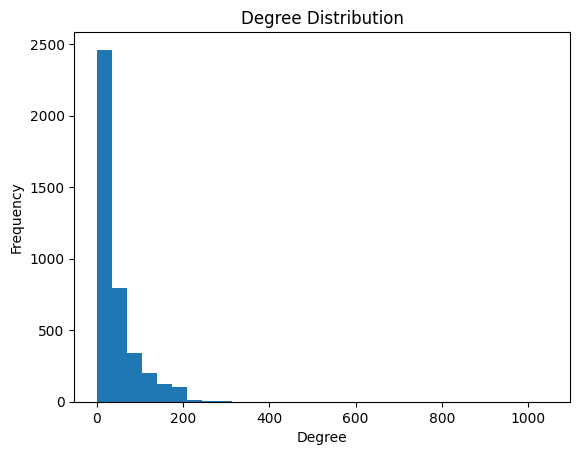

In [4]:
# Degree Distribution
degrees = [d for n, d in G.degree()]
plt.hist(degrees, bins=30)
plt.title('Degree Distribution')
plt.xlabel('Degree')
plt.ylabel('Frequency')
plt.show()

In [5]:
# Network Metrics
print('Average Degree:', sum(dict(G.degree()).values())/G.number_of_nodes())
print('Density:', nx.density(G))
print('Global Clustering Coefficient:', nx.transitivity(G))

# Local clustering for a sample node
node = list(G.nodes())[0]
print('Local Clustering Coefficient of node', node, ':', nx.clustering(G, node))

Average Degree: 43.69101262688784
Density: 0.010819963503439287
Global Clustering Coefficient: 0.5191742775433075
Local Clustering Coefficient of node 0 : 0.04196165314587463


In [13]:
#Diameter, Density & Avg Path Length
largest_cc = max(nx.connected_components(G), key=len)
subgraph = G.subgraph(largest_cc)

print("Graph Density:", nx.density(G))

from networkx.algorithms.approximation import diameter
print("Approximate Diameter:", diameter(subgraph))

import random
def approximate_avg_path_length(G, sample_size=100):
    nodes = list(G.nodes())
    sample_nodes = random.sample(nodes, sample_size)
    lengths = []
    for node in sample_nodes:
        sp = nx.single_source_shortest_path_length(G, node)
        lengths.extend(sp.values())
    return sum(lengths) / len(lengths)

print("Approximate Average Path Length:", approximate_avg_path_length(subgraph))

Graph Density: 0.010819963503439287
Approximate Diameter: 8
Approximate Average Path Length: 3.7254939341421145


# Part II – Ego Network Analysis

Task 1 : Now, Download the Datasets from SNAP Facebook Dataset

In [9]:
!wget https://snap.stanford.edu/data/facebook.tar.gz
!tar -xzf facebook.tar.gz

--2026-01-27 09:00:53--  https://snap.stanford.edu/data/facebook.tar.gz
Resolving snap.stanford.edu (snap.stanford.edu)... 171.64.75.80
Connecting to snap.stanford.edu (snap.stanford.edu)|171.64.75.80|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 732104 (715K) [application/x-gzip]
Saving to: ‘facebook.tar.gz’

facebook.tar.gz     100%[===================>] 714.95K  1.07MB/s    in 0.7s    

2026-01-27 09:00:54 (1.07 MB/s) - ‘facebook.tar.gz’ saved [732104/732104]



Task 2 : Load the Facebook dataset from SNAP and create a graph object.

In [10]:
import os

ego_files = [f for f in os.listdir('facebook') if f.endswith('.edges')]
print('Ego Nodes:', ego_files)

Ego Nodes: ['686.edges', '3980.edges', '348.edges', '1684.edges', '1912.edges', '698.edges', '3437.edges', '0.edges', '107.edges', '414.edges']


Task 3 : Identify the ego nodes in the dataset. These are the nodes around which ego networks are centered.

Task 4 : For each ego node, extract its ego network and analyze its properties such as clustering
coefficient, number of triangles, average path length and diameter

In [11]:
for file in ego_files[:5]:  # limiting to first 5 for speed
    ego_id = file.split('.')[0]
    G_ego = nx.read_edgelist(os.path.join('facebook', file), nodetype=int)
    print(f"\nEgo Node: {ego_id}")
    print('Nodes:', G_ego.number_of_nodes())
    print('Edges:', G_ego.number_of_edges())
    print('Clustering Coefficient:', nx.average_clustering(G_ego))
    print('Triangles:', sum(nx.triangles(G_ego).values())//3)
    if nx.is_connected(G_ego):
        print('Diameter:', nx.diameter(G_ego))
        print('Average Path Length:', nx.average_shortest_path_length(G_ego))


Ego Node: 686
Nodes: 168
Edges: 1656
Clustering Coefficient: 0.5337913395248177
Triangles: 7945
Diameter: 6
Average Path Length: 2.4250784145993727

Ego Node: 3980
Nodes: 52
Edges: 146
Clustering Coefficient: 0.46172685095196403
Triangles: 168

Ego Node: 348
Nodes: 224
Edges: 3192
Clustering Coefficient: 0.5442814709697877
Triangles: 23503
Diameter: 9
Average Path Length: 2.523462524023062

Ego Node: 1684
Nodes: 786
Edges: 14024
Clustering Coefficient: 0.4757300518398769
Triangles: 121532

Ego Node: 1912
Nodes: 747
Edges: 30025
Clustering Coefficient: 0.6354046451180386
Triangles: 916277


Task 5 : Visualize Ego networks using NetworkX and Matplotlib

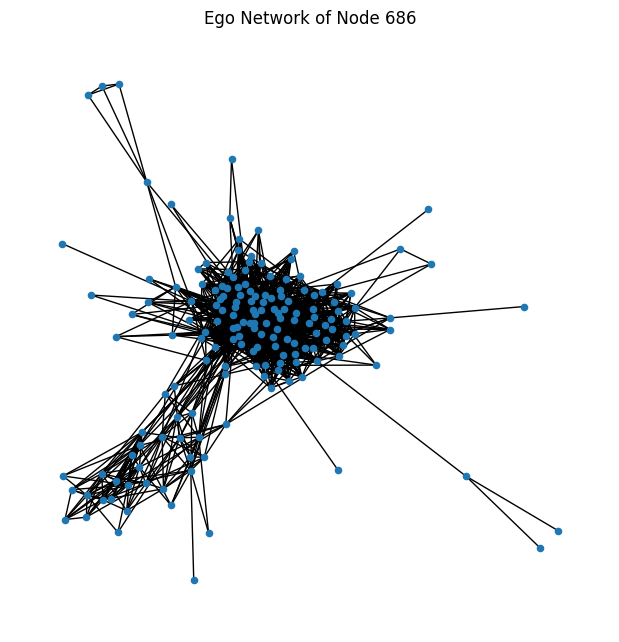

In [12]:
ego_id = ego_files[0].split('.')[0]
G_ego = nx.read_edgelist(os.path.join('facebook', ego_files[0]), nodetype=int)
plt.figure(figsize=(6,6))
nx.draw(G_ego, node_size=20)
plt.title(f'Ego Network of Node {ego_id}')
plt.show()